<div style="background:linear-gradient(135deg,#0D1B2A 0%,#1565C0 100%);padding:36px 40px;border-radius:12px;margin-bottom:8px;">
  <div style="display:flex;align-items:center;gap:16px;">
    <span style="font-size:48px;">🛰️</span>
    <div>
      <p style="color:#ADE8F4;margin:0;font-size:13px;letter-spacing:3px;text-transform:uppercase;font-family:monospace;">Computer Vision for Remote Sensing · Bangladesh</p>
      <h1 style="color:#FFFFFF;margin:4px 0 0 0;font-size:28px;font-family:monospace;">Phase 1 · Raster CV Foundations</h1>
    </div>
  </div>
  <hr style="border-color:#1E88E5;margin:20px 0 16px 0;"/>
  <div style="display:flex;gap:32px;flex-wrap:wrap;">
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">📘 Lesson <b style="color:#FFF">L2 / 7</b></span>
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">⏱ Est. Time <b style="color:#FFF">2 hrs</b></span>
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">📍 Study Area <b style="color:#FFF">Sitakunda / EPZ</b></span>
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">📅 Date <b style="color:#FFF">____-__-__</b></span>
  </div>
</div>
<div style="background:#1565C022;border-left:5px solid #1565C0;padding:18px 24px;border-radius:0 8px 8px 0;">
  <h2 style="color:#1565C0;margin:0 0 8px 0;font-size:18px;">📖 L2 — Spatial Profile & Georeferencing</h2>
  <p style="margin:0;color:#1A2A3A;font-size:14px;">📝 <i>Add lesson description here — what is this lesson about?</i></p>
</div>

## 🎯 Objectives

By the end of this lesson you will be able to:

- ✅ Read and understand every key in a raster profile dictionary
- ✅ Explain what the Affine Transform is and how it georeferences pixels
- ✅ Copy a profile correctly using `profile.copy()`
- ✅ Update only dtype and nodata without touching CRS or transform
- ✅ Write a cleaned GeoTIFF that opens correctly in QGIS/ArcGIS

---

## 🔑 Key Functions

| Function | Purpose |
|---|---|
| `src.profile` | Read full metadata dictionary of raster |
| `profile.copy()` | Copy profile independently — never modify original |
| `profile.update({...})` | Change specific keys only (dtype, nodata) |
| `rasterio.open(path, 'w', **profile)` | Write new GeoTIFF with profile settings |
| `dst.write(array, 1)` | Write array to band 1 of output file |
| `src.transform` | Affine transform — maps pixel → real coordinates |
| `src.crs` | Coordinate Reference System of the file |
| `array.astype('float32')` | Convert dtype before writing |
| `np.where(arr == -9999, np.nan, arr)` | Replace nodata value with NaN |
| `np.nanmin() / np.nanmax()` | Statistics ignoring NaN values |

---
## ⚙️ Setup & Imports

In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import json

# ── Paths ──────────────────────────────────────────────────────────────────
TIF_PATH = pathlib.Path(r"H:/gis all/github cv/2004-03-02/LST_2004-03-02_LT05.tif")
FIG_DIR  = pathlib.Path("../../outputs/figures/phase1/")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"rasterio : {rasterio.__version__}")
print(f"File OK  : {TIF_PATH.exists()}")

rasterio : 1.4.4
File OK  : True


In [2]:
# ── Cell 2: Read & Print Full Profile ─────────────────────────────────────
with rasterio.open(TIF_PATH) as src:
    profile = src.profile

print("=" * 52)
print("  FULL PROFILE DICTIONARY")
print("=" * 52)
for key, value in profile.items():
    print(f"  {key:15s} : {value}")

  FULL PROFILE DICTIONARY
  driver          : GTiff
  dtype           : float64
  nodata          : -9999.0
  width           : 199
  height          : 143
  count           : 1
  crs             : EPSG:4326
  transform       : | 0.00, 0.00, 90.42|
| 0.00,-0.00, 23.73|
| 0.00, 0.00, 1.00|
  blockxsize      : 256
  blockysize      : 256
  tiled           : True
  compress        : deflate
  interleave      : band


In [3]:
# ── Cell 4: The Transform Explained ───────────────────────────────────────
with rasterio.open(TIF_PATH) as src:
    t = src.transform

print("=" * 52)
print("  AFFINE TRANSFORM")
print("=" * 52)
print(f"\n  Full transform:\n  {t}")
print(f"\n  Pixel width  (x resolution) : {t.a:.8f} degrees")
print(f"  Pixel height (y resolution) : {t.e:.8f} degrees")
print(f"  Top-left X   (longitude)    : {t.c:.6f}")
print(f"  Top-left Y   (latitude)     : {t.f:.6f}")
print(f"\n  In metres (approx at Bangladesh latitude):")
print(f"  Pixel width  ≈ {abs(t.a) * 111320:.1f} m")
print(f"  Pixel height ≈ {abs(t.e) * 111320:.1f} m")

  AFFINE TRANSFORM

  Full transform:
  | 0.00, 0.00, 90.42|
| 0.00,-0.00, 23.73|
| 0.00, 0.00, 1.00|

  Pixel width  (x resolution) : 0.00026949 degrees
  Pixel height (y resolution) : -0.00026949 degrees
  Top-left X   (longitude)    : 90.422979
  Top-left Y   (latitude)     : 23.733310

  In metres (approx at Bangladesh latitude):
  Pixel width  ≈ 30.0 m
  Pixel height ≈ 30.0 m


In [5]:
# ── Cell 5: Copy Profile & Write Clean Output ──────────────────────────────
with rasterio.open(TIF_PATH) as src:
    img    = src.read()
    profile = src.profile.copy()        # copy original profile
    nodata  = src.nodata

# Mask nodata
lst_masked = np.where(img[0] == nodata, np.nan, img[0])

# Update profile for output file
new_profile = profile.copy()
new_profile.update({
    'dtype'  : 'float32',       # save as float32 (smaller than float64)
    'nodata' : np.nan,          # use NaN as nodata instead of -9999
    'count'  : 1,
})

# ── Fix OUT_PATH to your actual folder ────────────────────────────────────
OUT_PATH = pathlib.Path(r"C:/Users/sahri/Downloads/geospatial-cv-roadmap/outputs/LST_2004_cleaned.tif")
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)  # creates folder if needed

with rasterio.open(OUT_PATH, 'w', **new_profile) as dst:
    dst.write(lst_masked.astype('float32'), 1)

print(f"✓ Saved → {OUT_PATH}")

print("=" * 52)
print("  WRITE OUTPUT — PROFILE COMPARISON")
print("=" * 52)
print(f"\n  Original profile:")
print(f"    dtype  : {profile['dtype']}")
print(f"    nodata : {profile['nodata']}")
print(f"\n  New profile:")
print(f"    dtype  : {new_profile['dtype']}")
print(f"    nodata : {new_profile['nodata']}")
print(f"\n  ✓ Cleaned file saved → {OUT_PATH}")
print(f"  Georeferencing preserved: CRS + Transform unchanged ✅")

✓ Saved → C:\Users\sahri\Downloads\geospatial-cv-roadmap\outputs\LST_2004_cleaned.tif
  WRITE OUTPUT — PROFILE COMPARISON

  Original profile:
    dtype  : float64
    nodata : -9999.0

  New profile:
    dtype  : float32
    nodata : nan

  ✓ Cleaned file saved → C:\Users\sahri\Downloads\geospatial-cv-roadmap\outputs\LST_2004_cleaned.tif
  Georeferencing preserved: CRS + Transform unchanged ✅


In [6]:
# ── Cell 6: Verify Output File ─────────────────────────────────────────────
with rasterio.open(OUT_PATH) as src:
    img_clean = src.read(1)
    
    print("=" * 52)
    print("  VERIFY CLEANED OUTPUT FILE")
    print("=" * 52)
    print(f"  Shape      : {img_clean.shape}")
    print(f"  dtype      : {src.dtypes[0]}")
    print(f"  nodata     : {src.nodata}")
    print(f"  CRS        : {src.crs}")
    print(f"  Transform  : {src.transform}")
    print(f"  Min temp   : {np.nanmin(img_clean):.2f} °C")
    print(f"  Max temp   : {np.nanmax(img_clean):.2f} °C")
    print(f"  Mean temp  : {np.nanmean(img_clean):.2f} °C")
    print(f"\n  CRS same as original   : {src.crs == profile['crs']} ✅")
    print(f"  Size reduced           : float64→float32 = 50% smaller ✅")
    print(f"  NoData changed         : -9999 → NaN ✅")

  VERIFY CLEANED OUTPUT FILE
  Shape      : (143, 199)
  dtype      : float32
  nodata     : nan
  CRS        : EPSG:4326
  Transform  : | 0.00, 0.00, 90.42|
| 0.00,-0.00, 23.73|
| 0.00, 0.00, 1.00|
  Min temp   : 24.42 °C
  Max temp   : 38.23 °C
  Mean temp  : 30.25 °C

  CRS same as original   : True ✅
  Size reduced           : float64→float32 = 50% smaller ✅
  NoData changed         : -9999 → NaN ✅


NameError: name 'OUTPUT_DIR' is not defined

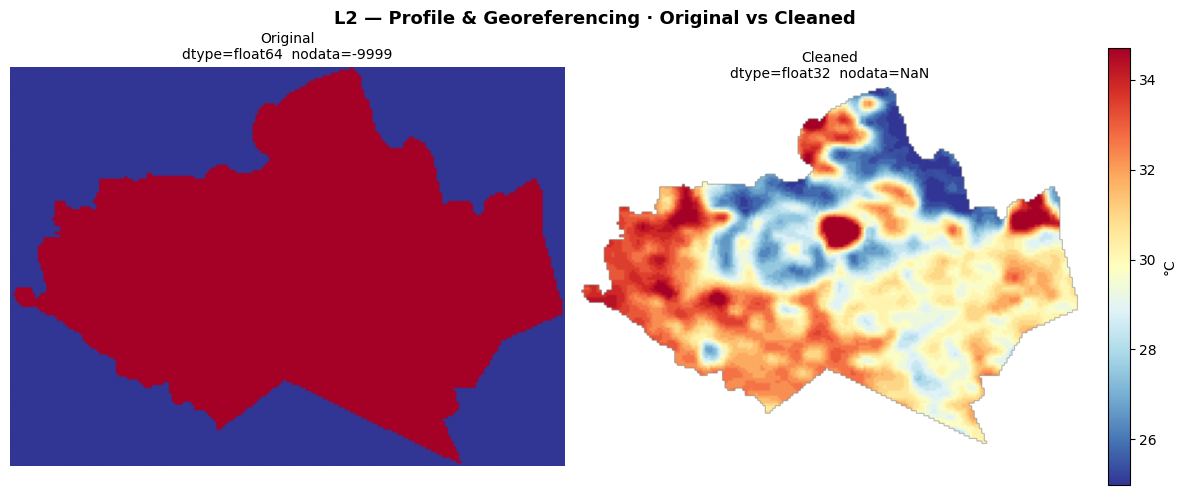

In [7]:
# ── Cell 7: Visualize Comparison ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('L2 — Profile & Georeferencing · Original vs Cleaned',
             fontsize=13, fontweight='bold')

# Original
with rasterio.open(TIF_PATH) as src:
    original = src.read(1)
axes[0].imshow(original, cmap='RdYlBu_r')
axes[0].set_title('Original\ndtype=float64  nodata=-9999', fontsize=10)
axes[0].axis('off')

# Cleaned
lo = np.nanpercentile(img_clean, 2)
hi = np.nanpercentile(img_clean, 98)
im = axes[1].imshow(img_clean, cmap='RdYlBu_r', vmin=lo, vmax=hi)
plt.colorbar(im, ax=axes[1], label='°C', fraction=0.046)
axes[1].set_title('Cleaned\ndtype=float32  nodata=NaN', fontsize=10)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'L2_profile_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved → outputs/figures/phase1/L2_profile_comparison.png")

In [8]:
# ── Cell 8: Key Takeaways Summary ──────────────────────────────────────────
print("""
L2 COMPLETE — KEY LEARNING
══════════════════════════════════════════════════
profile = src.profile          → full metadata dict
profile.copy()                 → always copy before modifying
profile.update({...})          → change only what you need
rasterio.open(path,'w',**profile) → write preserving georef

YOUR FILE:
  CRS        : EPSG:4326 (fix → 32646 in L4)
  Transform  : top-left (90.42, 23.73) = Jatrabari
  Pixel size : 0.00027° ≈ 30m (Landsat standard)
  Cleaned    : float64→float32, -9999→NaN

RULE: Always profile.copy() — never modify original
══════════════════════════════════════════════════
""")


L2 COMPLETE — KEY LEARNING
══════════════════════════════════════════════════
profile = src.profile          → full metadata dict
profile.copy()                 → always copy before modifying
profile.update({...})          → change only what you need
rasterio.open(path,'w',**profile) → write preserving georef

YOUR FILE:
  CRS        : EPSG:4326 (fix → 32646 in L4)
  Transform  : top-left (90.42, 23.73) = Jatrabari
  Pixel size : 0.00027° ≈ 30m (Landsat standard)
  Cleaned    : float64→float32, -9999→NaN

RULE: Always profile.copy() — never modify original
══════════════════════════════════════════════════



---
## 🏋️ Exercise

<div style="background:#FFF9C4;border-left:4px solid #F9A825;padding:14px 20px;border-radius:0 8px 8px 0;">
<b>Task:</b> Spatial Profile & Georeferencing — complete the exercise below.
</div>

In [ ]:
# ── YOUR CODE HERE ────────────────────────────────────────────────────────


---
## 📝 My Notes

> _Fill in after completing the exercise._

- Observation 1: `____`
- Observation 2: `____`
- Anything unexpected: `____`


---
<div style="background:linear-gradient(135deg,#0D1B2A 0%,#1565C0 100%);padding:24px 32px;border-radius:10px;">
  <h2 style="color:#FFFFFF;margin:0 0 12px 0;font-size:18px;">✅ Key Takeaways — L2</h2>
  <ul style="color:#C8E6C9;font-size:14px;line-height:2.2;margin:0;">
    <li>_Takeaway 1_</li>
    <li>_Takeaway 2_</li>
    <li>_Takeaway 3_</li>
  </ul>
</div>

---
<div style="display:flex;justify-content:space-between;padding:10px 0;font-size:13px;color:#9E9E9E;">
  <span>← Previous: <a href="L1_prev.ipynb">L1</a></span>
  <b style="color:#1565C0;">Phase 1 · L2 of 7</b>
  <span><a href="L3_next.ipynb" style="color:#1565C0;">Next: L3 →</a></span>
</div>